In [5]:
import os
import shutil
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

Outlier Summary:
Happy: {'non_gray': 461, 'non_48x48': 461, 'total': 18439}
Suprise: {'non_gray': 223, 'non_48x48': 223, 'total': 8227}
Sad: {'non_gray': 397, 'non_48x48': 399, 'total': 12553}
Fear: {'non_gray': 18, 'non_48x48': 18, 'total': 9732}
Angry: {'non_gray': 242, 'non_48x48': 242, 'total': 10148}


/tmp/ipykernel_29998/1079380525.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


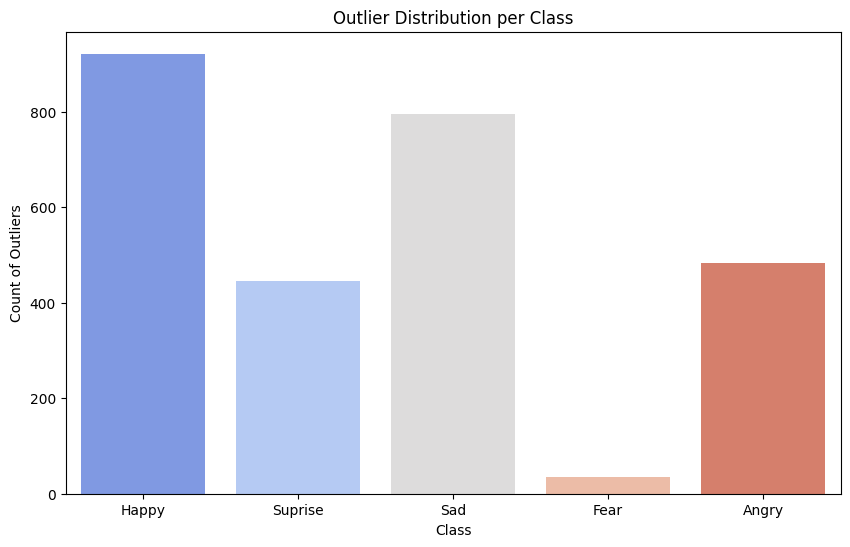

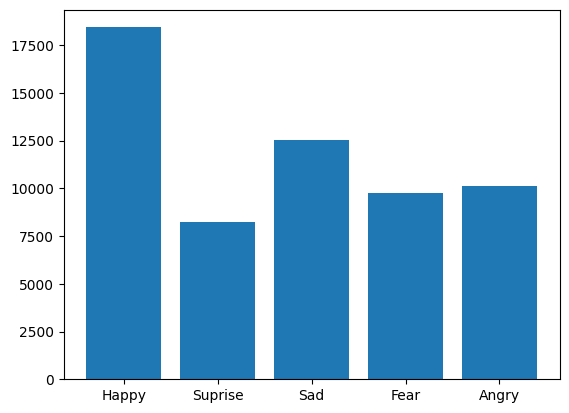

In [4]:
data_dir = "./Data"
classes = os.listdir(data_dir)

# Track counts
outlier_counts = defaultdict(lambda: {"non_gray": 0, "non_48x48": 0, "total": 0})

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        try:
            img = Image.open(fpath)
            outlier_counts[cls]["total"] += 1

            # Check if grayscale
            if img.mode != "L":
                outlier_counts[cls]["non_gray"] += 1

            # Check if not 48x48
            if img.size != (48, 48):
                outlier_counts[cls]["non_48x48"] += 1

        except Exception as e:
            print(f"[Error] {fpath}: {e}")

# Print summary
print("Outlier Summary:")
for cls, stats in outlier_counts.items():
    print(f"{cls}: {stats}")

# Plot distribution
plt.figure(figsize=(10, 6))
sns.barplot(
    x=list(outlier_counts.keys()),
    y=[outlier_counts[c]["non_gray"] + outlier_counts[c]["non_48x48"] for c in classes],
    palette="coolwarm"
)
plt.title("Outlier Distribution per Class")
plt.ylabel("Count of Outliers")
plt.xlabel("Class")
plt.show()

counts = [len(os.listdir(os.path.join(data_dir, c))) for c in classes]
plt.bar(classes, counts)
plt.show()

## TRANSFORMATION

In [6]:
outlier_dir = "./outliers"
os.makedirs(outlier_dir, exist_ok=True)

for cls in classes:
    src_class_path = os.path.join(data_dir, cls)
    dst_class_path = os.path.join(outlier_dir, cls)
    os.makedirs(dst_class_path, exist_ok=True)

    for fname in os.listdir(src_class_path):
        fpath = os.path.join(src_class_path, fname)
        try:
            img = Image.open(fpath)

            if img.mode != "L" or img.size != (48, 48):
                shutil.move(fpath, os.path.join(dst_class_path, fname))
                print(f"Moved outlier: {fpath}")

        except Exception as e:
            print(f"[Error moving] {fpath}: {e}")


Moved outlier: ./Data/Happy/1HEoLBLidT2u4mhJ0oiDgig.png
Moved outlier: ./Data/Happy/7-principles-of-successful-and-happy-people.png
Moved outlier: ./Data/Happy/image-368.jpeg
Moved outlier: ./Data/Happy/nathan-dumlao-26rK1-bH9Ls-unsplash.jpg
Moved outlier: ./Data/Happy/happy232_jpg.rf.13d53e684124ef1a85bcb5a14e1ea275.jpg
Moved outlier: ./Data/Happy/image-590.jpeg
Moved outlier: ./Data/Happy/happy81_jpg.rf.61359e1877aad9a89d9475f3a69d99f0.jpg
Moved outlier: ./Data/Happy/image-491.jpeg
Moved outlier: ./Data/Happy/happy275_jpg.rf.010e9ddab95904151dfc00fc83259147.jpg
Moved outlier: ./Data/Happy/happy204_jpg.rf.bb93c276baa75925d8cfec47e4edc192.jpg
Moved outlier: ./Data/Happy/happy245_jpg.rf.ba9613e85708f7cbeeb807b4d43e92d4.jpg
Moved outlier: ./Data/Happy/image-495.jpeg
Moved outlier: ./Data/Happy/happy127_jpg.rf.1892e25ddc7ddc845da51e7336c49f0d.jpg
Moved outlier: ./Data/Happy/image-571.jpeg
Moved outlier: ./Data/Happy/happy-person.jpeg
Moved outlier: ./Data/Happy/happy132_jpg.rf.bf9eb19769a

In [7]:
valid_count = 0
for cls in classes:
    class_path = os.path.join(data_dir, cls)
    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        try:
            img = Image.open(fpath)
            if img.mode == "L" and img.size == (48, 48):
                valid_count += 1
        except:
            pass

print(f"All clean images count: {valid_count}")


All clean images count: 57756


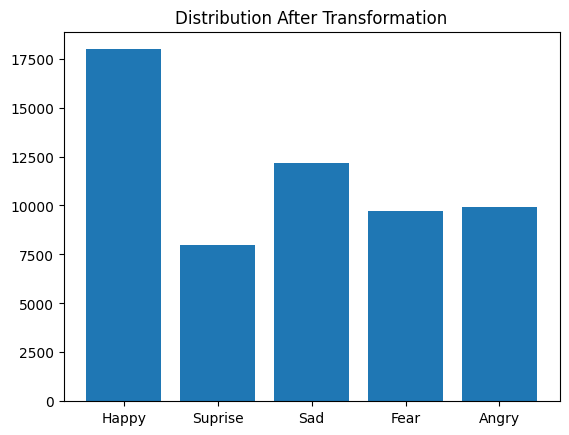

In [15]:
counts = [len(os.listdir(os.path.join(data_dir, c))) for c in classes]
plt.bar(classes, counts)
plt.title("Distribution After Transformation")
plt.show()

In [16]:
print(counts)

[17978, 8004, 12154, 9714, 9906]
